# Clase 5: Mapas Coropléticos

**Curso: Análisis de Datos Espaciales con Python**

> **Referencia:** Este material está basado en el capítulo *Choropleth Mapping* del libro  
> *Geographic Data Science with Python* de Rey, Arribas-Bel y Wolf (2020),  
> disponible en: https://geographicdata.science/book/notebooks/05_choropleth.html  
> Licencia CC BY-NC-ND 4.0.

## 1. ¿Qué es un mapa coroplético?

La palabra *coropleta* proviene de la raíz griega **"choro"** que significa *región*. Un **mapa coroplético** es un mapa geográfico que muestra información estadística codificada mediante una paleta de colores.

### Características principales

- Representan datos a **nivel de región** (polígonos).
- Cada observación combina un **valor de atributo** con una **figura geométrica**.
- Los valores del atributo se agrupan en un **número reducido de clases** (generalmente < 12).
- Cada clase se asocia a un **símbolo o color único**.

### ¿Por qué clasificar si hoy podemos hacer mapas sin clases?

Aunque hoy es técnicamente posible asignar un color distinto a cada valor (*mapa sin clases*), la clasificación sigue siendo útil porque **reduce la carga cognitiva** al interpretar el mapa, apoyándose en la teoría estadística y de visualización.

### Las tres dimensiones clave del diseño coroplético

1. **Número de clases:** ¿en cuántos grupos dividimos los datos?
2. **Algoritmo de clasificación:** ¿qué regla usamos para asignar cada valor a un grupo?
3. **Esquema de color:** ¿qué colores asignamos a cada clase?

## 2. Configuración del entorno

Importamos las librerías necesarias.

In [5]:
import seaborn
import pandas
import geopandas
import numpy
import matplotlib.pyplot as plt
import mapclassify

# Configuración visual
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 6)

## 3. Datos de ejemplo: Ingreso regional de México

Trabajaremos con datos de ingreso per cápita (PIB per cápita) de los 32 estados de México. La variable principal es `PCGDP1940` (PIB per cápita en 1940).

> **Fuente:** Rey y Sastré-Gutiérrez (2010). *Interregional inequality dynamics in Mexico*.

In [6]:
# Carga de datos
# Si usas los datos del libro:
# mx = geopandas.read_file("../data/mexico/mexicojoin.shp")

# Alternativa: descargar directamente del repositorio del libro
mx = geopandas.read_file(
    "https://github.com/gdsbook/book/raw/master/data/mexico/mexicojoin.shp"
)

mx[["NAME", "PCGDP1940"]].head()

,NAME,PCGDP1940
0,Baja California Norte,22361.0
1,Baja California Sur,9573.0
2,Nayarit,4836.0
3,Jalisco,5309.0
4,Aguascalientes,10384.0


### 3.1 Distribución estadística de la variable

Antes de clasificar, siempre debemos inspeccionar la distribución de nuestros datos. Esto nos ayudará a elegir el clasificador más adecuado.

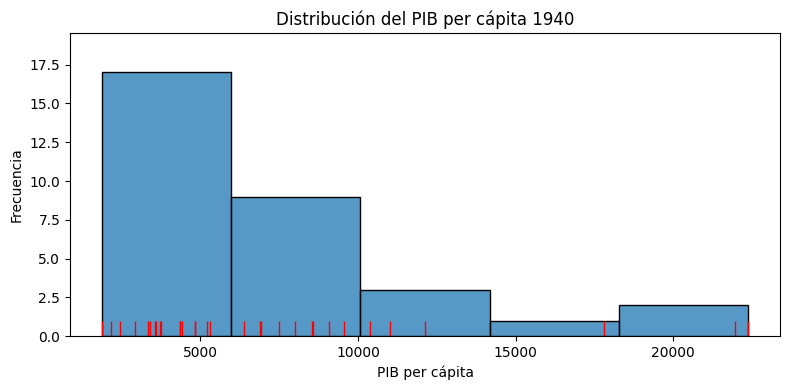

In [7]:
# Histograma con alfombra (rug plot)
fig, ax = plt.subplots(1, figsize=(8, 4))
seaborn.histplot(mx["PCGDP1940"], bins=5, ax=ax)
seaborn.rugplot(mx["PCGDP1940"], height=0.05, color="red", ax=ax)
ax.set_title("Distribución del PIB per cápita 1940")
ax.set_xlabel("PIB per cápita")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [8]:
# Estadísticas descriptivas
mx["PCGDP1940"].describe()

count       32.000000
mean      7230.531250
std       5204.952883
min       1892.000000
25%       3701.750000
50%       5256.000000
75%       8701.750000
max      22361.000000
Name: PCGDP1940, dtype: float64

**Observación:** La distribución presenta **asimetría positiva** (la media supera a la mediana), lo cual genera una cola derecha larga. Esta asimetría tendrá implicaciones para la elección del esquema de clasificación.

## 4. Esquemas de clasificación de datos cuantitativos

### El problema formal de clasificación

Dado un conjunto de valores ordenados $x_0 \le x_1 \le \ldots \le x_{n-1}$ y un número predefinido de clases $k$, el problema consiste en seleccionar $k-1$ **puntos de corte** que separen los valores en grupos mutuamente excluyentes y exhaustivos:

$$c_j < y_i \le c_{j+1} \quad \forall \, y_i \in C_j$$

Veamos distintos algoritmos para resolver este problema.

### 4.1 Intervalos iguales (*Equal Intervals*)

Divide el rango total de valores en $k$ intervalos de **igual ancho**:

$$w = \frac{x_{n-1} - x_0}{k}$$

**Ventajas:** Simple y fácil de interpretar.  
**Desventajas:** Solo considera los valores extremos; puede generar clases vacías o muy dispersas si los datos son asimétricos.

In [9]:
ei5 = mapclassify.EqualInterval(mx["PCGDP1940"], k=5)
ei5

EqualInterval

      Interval         Count
----------------------------
[ 1892.00,  5985.80] |    17
( 5985.80, 10079.60] |     9
(10079.60, 14173.40] |     3
(14173.40, 18267.20] |     1
(18267.20, 22361.00] |     2

Observa cómo las dos primeras clases concentran 26 de los 32 estados, mientras que las tres últimas están muy poco pobladas. Esto se debe a la asimetría de la distribución.

### 4.2 Cuantiles (*Quantiles*)

Usa los cuantiles de la distribución como límites de clase, logrando que cada clase tenga **aproximadamente el mismo número de observaciones** ($\approx n/k$).

**Ventajas:** Evita clases vacías.  
**Desventajas:** Los anchos de los intervalos pueden ser muy diferentes, dificultando la interpretación. Además, puede haber problemas con **empates** (muchos valores repetidos).

In [10]:
q5 = mapclassify.Quantiles(mx["PCGDP1940"], k=5)
q5

Quantiles

      Interval         Count
----------------------------
[ 1892.00,  3576.20] |     7
( 3576.20,  4582.80] |     6
( 4582.80,  6925.20] |     6
( 6925.20,  9473.00] |     6
( 9473.00, 22361.00] |     7

In [11]:
# Diferencia de anchos entre intervalos consecutivos
print("Anchos de intervalos:", q5.bins[1:] - q5.bins[:-1])

Anchos de intervalos: [ 1006.6  2342.4  2547.8 12888. ]


#### Ejemplo: problema de empates

Cuando hay muchos valores repetidos, la clasificación por cuantiles puede producir clases ambiguas.

In [12]:
# Variable sintética con muchos empates
numpy.random.seed(12345)
x = numpy.random.randint(0, 10, 20)
x[0:10] = x.min()
print("Valores:", x)
print("Valores únicos:", numpy.unique(x))

# Clasificación por cuantiles
ties = mapclassify.Quantiles(x, k=5)
ties

Valores: [0 0 0 0 0 0 0 0 0 0 9 7 6 0 2 9 1 2 6 7]
Valores únicos: [0 1 2 6 7 9]


/Users/daniela/Documents/usm/cursos/geodata/.venv/lib/python3.11/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 4.
  self.bins = quantile(y, k=k)


Quantiles

  Interval     Count
--------------------
[0.00, 0.00] |    11
(0.00, 1.40] |     1
(1.40, 6.20] |     4
(6.20, 9.00] |     4

**Nota:** `mapclassify` emitirá una advertencia indicando que no hay suficientes valores únicos para formar las 5 clases solicitadas, y usará *pseudo-cuantiles* en su lugar.

### 4.3 Media-desviación estándar (*Mean-Standard Deviation*)

Define los límites de clase como **múltiplos de la desviación estándar** alrededor de la media:

- Clase 1: $(-\infty, \bar{x} - 2s]$  
- Clase 2: $(\bar{x} - 2s, \bar{x} - s]$  
- Clase 3: $(\bar{x} - s, \bar{x} + s]$  
- Clase 4: $(\bar{x} + s, \bar{x} + 2s]$  
- Clase 5: $(\bar{x} + 2s, +\infty)$

**Ideal para:** datos con distribución normal o simétrica.  
**Problemas:** Con datos asimétricos, concentra la mayoría en la clase central.

In [13]:
msd = mapclassify.StdMean(mx["PCGDP1940"])
msd

StdMean

      Interval         Count
----------------------------
(    -inf, -3179.37] |     0
(-3179.37,  2025.58] |     1
( 2025.58, 12435.48] |    28
(12435.48, 17640.44] |     0
(17640.44, 22361.00] |     3

Observa cómo 28 de 32 estados caen en la clase central, y la primera clase tiene un límite superior negativo (inadmisible para ingresos).

### 4.4 Cortes máximos (*Maximum Breaks*)

Coloca los $k-1$ puntos de corte donde las **diferencias entre valores consecutivos** (una vez ordenados) son mayores. El algoritmo busca las brechas más grandes en la distribución.

**Ventajas:** Bueno cuando los datos son multimodales; algoritmo rápido.  
**Desventajas:** Solo considera las diferencias más grandes, ignorando matices dentro de las clases.

In [14]:
mb5 = mapclassify.MaximumBreaks(mx["PCGDP1940"], k=5)
mb5

MaximumBreaks

      Interval         Count
----------------------------
[ 1892.00,  5854.00] |    17
( 5854.00, 11574.00] |    11
(11574.00, 14974.00] |     1
(14974.00, 19890.50] |     1
(19890.50, 22361.00] |     2

### 4.5 Diagrama de caja (*Box Plot*)

Combina las ideas de cuantiles y desviación estándar. Genera **6 clases** fijas usando los percentiles 25, 50 y 75, más "bigotes" definidos por el rango intercuartílico (IQR) multiplicado por una bisagra $h$:

- Outliers inferiores: $(-\infty, Q1 - h \cdot IQR]$
- Clase 2: $(Q1 - h \cdot IQR, Q1]$
- Clase 3: $(Q1, Q2]$ (mediana)
- Clase 4: $(Q2, Q3]$
- Clase 5: $(Q3, Q3 + h \cdot IQR]$
- Outliers superiores: $(Q3 + h \cdot IQR, +\infty)$

In [15]:
bp = mapclassify.BoxPlot(mx["PCGDP1940"])
bp

BoxPlot

      Interval         Count
----------------------------
(    -inf, -3798.25] |     0
(-3798.25,  3701.75] |     8
( 3701.75,  5256.00] |     8
( 5256.00,  8701.75] |     8
( 8701.75, 16201.75] |     5
(16201.75, 22361.00] |     3

In [16]:
# Con una bisagra diferente (h=1 en lugar de h=1.5)
bp1 = mapclassify.BoxPlot(mx["PCGDP1940"], hinge=1)
bp1

BoxPlot

      Interval         Count
----------------------------
(    -inf, -1298.25] |     0
(-1298.25,  3701.75] |     8
( 3701.75,  5256.00] |     8
( 5256.00,  8701.75] |     8
( 8701.75, 13701.75] |     5
(13701.75, 22361.00] |     3

### 4.6 Head-Tail Breaks

Algoritmo recursivo propuesto por Jiang (2013). Particiona los datos usando divisiones iterativas alrededor de la **media**. El proceso continúa hasta que las distribuciones dentro de cada clase ya no muestren colas pesadas.

**Ideal para:** distribuciones con colas pesadas (ley de potencia, log-normal).

In [17]:
ht = mapclassify.HeadTailBreaks(mx["PCGDP1940"])
ht

HeadTailBreaks

      Interval         Count
----------------------------
[ 1892.00,  7230.53] |    20
( 7230.53, 12244.42] |     9
(12244.42, 20714.00] |     1
(20714.00, 22163.00] |     1
(22163.00, 22361.00] |     1

### 4.7 Jenks-Caspall

Algoritmo **heurístico** que busca minimizar la suma de desviaciones absolutas alrededor de las medias de clase. Es el caso unidimensional del conocido algoritmo **K-Means**.

Proceso:
1. Comienza con una partición inicial (p. ej., cuantiles).
2. Considera movimientos de observaciones entre clases adyacentes.
3. Acepta el movimiento que más reduzca la función objetivo.
4. Repite hasta que no haya mejora posible.

In [18]:
numpy.random.seed(12345)
jc5 = mapclassify.JenksCaspall(mx["PCGDP1940"], k=5)
jc5

JenksCaspall

      Interval         Count
----------------------------
[ 1892.00,  2934.00] |     4
( 2934.00,  4414.00] |     9
( 4414.00,  6399.00] |     5
( 6399.00, 12132.00] |    11
(12132.00, 22361.00] |     3

### 4.8 Fisher-Jenks

Usa **programación dinámica** para minimizar la suma de desviaciones absolutas alrededor de las medianas de clase. A diferencia de Jenks-Caspall, **garantiza** encontrar la clasificación óptima para un $k$ dado.

In [19]:
numpy.random.seed(12345)
fj5 = mapclassify.FisherJenks(mx["PCGDP1940"], k=5)
fj5

FisherJenks

      Interval         Count
----------------------------
[ 1892.00,  5309.00] |    17
( 5309.00,  9073.00] |     8
( 9073.00, 12132.00] |     4
(12132.00, 17816.00] |     1
(17816.00, 22361.00] |     2

### 4.9 Max-P

Aplica el método *max-p* de construcción de regiones al caso de clasificación de mapas. Es heurístico (como Jenks-Caspall) y no garantiza optimalidad.

In [20]:
mp5 = mapclassify.MaxP(mx["PCGDP1940"], k=5)
mp5

MaxP

      Interval         Count
----------------------------
[ 1892.00,  3569.00] |     7
( 3569.00,  5309.00] |    10
( 5309.00,  7990.00] |     5
( 7990.00,  9573.00] |     4
( 9573.00, 22361.00] |     6

---

## 5. Comparación de esquemas de clasificación

### 5.1 Desviación absoluta alrededor de la mediana de clase (ADCM)

La métrica **ADCM** mide qué tan "compacta" es cada clase. Un valor **menor** indica un mejor ajuste. Esto nos permite comparar clasificadores para un mismo $k$.

/var/folders/4m/3wpqgpmj1mj_hgdh7mk_1g380000gn/T/ipykernel_20911/905180715.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  seaborn.barplot(


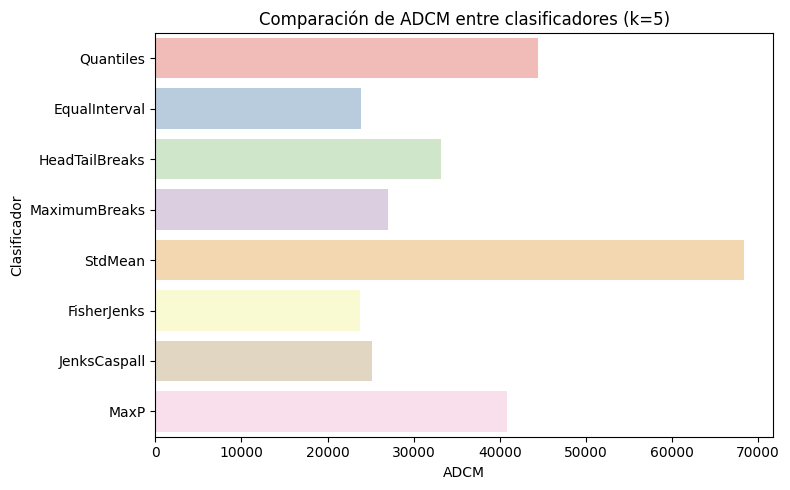

In [21]:
# Agrupar clasificadores
class5 = q5, ei5, ht, mb5, msd, fj5, jc5, mp5

# Calcular ADCM para cada uno
fits = numpy.array([c.adcm for c in class5])

# Crear DataFrame para visualización
adcms = pandas.DataFrame({
    "ADCM": fits,
    "Clasificador": [c.name for c in class5]
})

# Gráfico de barras
fig, ax = plt.subplots(1, figsize=(8, 5))
seaborn.barplot(
    y="Clasificador", x="ADCM", data=adcms,
    palette="Pastel1", ax=ax
)
ax.set_title("Comparación de ADCM entre clasificadores (k=5)")
plt.tight_layout()
plt.show()

**Interpretación:**
- **Fisher-Jenks** domina a todos los demás (menor ADCM), como es de esperarse dado que es el algoritmo óptimo.
- **Media-Desviación Estándar** tiene un ajuste muy pobre debido a la asimetría de los datos.
- **Intervalos Iguales** sorprendentemente funciona bien a pesar de su simplicidad.

### 5.2 Mapa de calor: ¿cómo clasifica cada algoritmo a cada estado?

In [22]:
# Añadir etiquetas de clase al GeoDataFrame
mx["Cuantiles"] = q5.yb
mx["Intervalos Iguales"] = ei5.yb
mx["Head-Tail Breaks"] = ht.yb
mx["Cortes Máximos"] = mb5.yb
mx["Media-Desv. Est."] = msd.yb
mx["Fisher-Jenks"] = fj5.yb
mx["Jenks Caspall"] = jc5.yb
mx["MaxP"] = mp5.yb

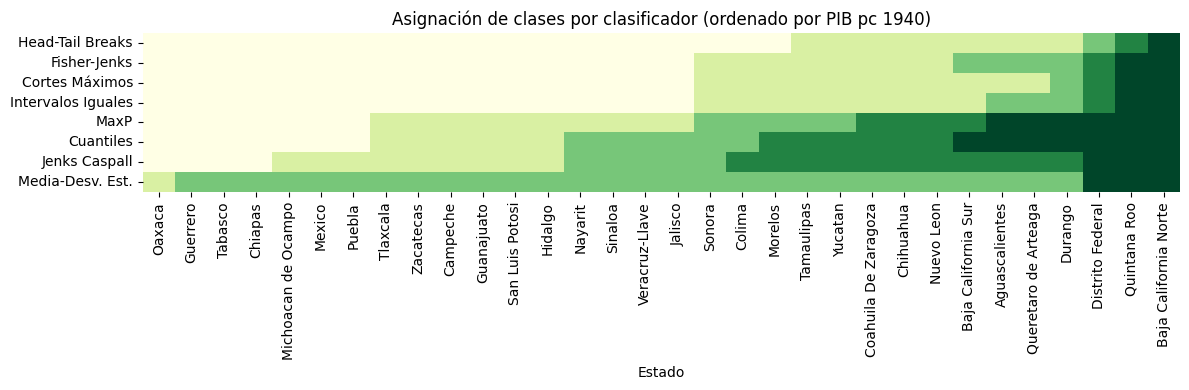

In [23]:
# Mapa de calor comparativo
cols_clasif = [
    "Head-Tail Breaks", "Fisher-Jenks", "Cortes Máximos",
    "Intervalos Iguales", "MaxP", "Cuantiles",
    "Jenks Caspall", "Media-Desv. Est."
]

f, ax = plt.subplots(1, figsize=(12, 4))
seaborn.heatmap(
    mx.set_index("NAME")
      .sort_values("PCGDP1940")[cols_clasif].T,
    cmap="YlGn",
    cbar=False,
    ax=ax,
)
ax.set_xlabel("Estado")
ax.set_title("Asignación de clases por clasificador (ordenado por PIB pc 1940)")
plt.tight_layout()
plt.show()

**¿Cómo leer este gráfico?**

- Cada **fila** es un clasificador.
- Cada **columna** es un estado (ordenado de menor a mayor PIB pc).
- El color va de amarillo claro (clase más baja) a verde oscuro (clase más alta).
- Baja California Norte es el **único estado** clasificado en la clase más alta por **todos** los algoritmos.
- El clasificador Media-Desv. Est. concentra casi todo en la clase central (2).

### 5.3 Conteos por clase

In [24]:
pandas.DataFrame(
    {c.name: c.counts for c in class5},
    index=[f"Clase-{i}" for i in range(5)],
)

,Quantiles,EqualInterval,HeadTailBreaks,MaximumBreaks,StdMean,FisherJenks,JenksCaspall,MaxP
Clase-0,7,17,20,17,0,17,4,7
Clase-1,6,9,9,11,1,8,9,10
Clase-2,6,3,1,1,28,4,5,5
Clase-3,6,1,1,1,0,1,11,4
Clase-4,7,2,1,2,3,2,3,6


---

## 6. Color: la tercera dimensión del diseño coroplético

La elección del color debe basarse en el **tipo de variable**. Existen tres tipos principales de paletas.

### 6.1 Paletas secuenciales

Apropiadas para **datos continuos** donde el origen está en un extremo de la serie (p. ej., ingresos, población, temperatura). Usan un gradiente de color de un tono claro a uno oscuro.

**Ejemplos:** `YlGn`, `Blues`, `Reds`, `viridis`.

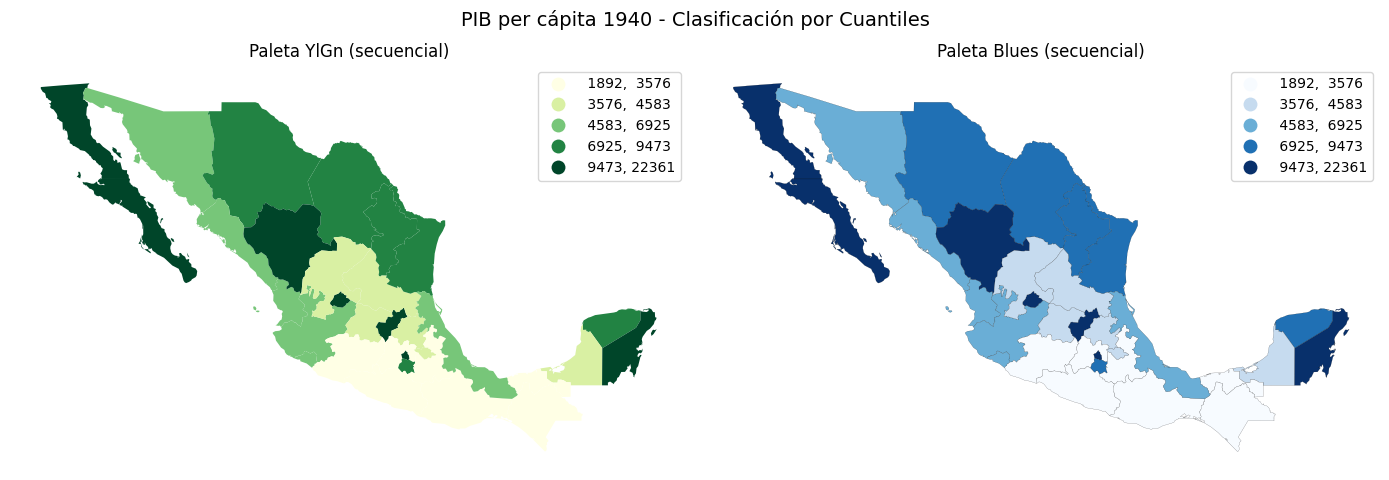

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Paleta YlGn
mx.plot(
    column="PCGDP1940", scheme="Quantiles", cmap="YlGn",
    legend=True, legend_kwds={"fmt": "{:.0f}"},
    ax=axes[0]
)
axes[0].set_axis_off()
axes[0].set_title("Paleta YlGn (secuencial)")

# Paleta Blues
mx.plot(
    column="PCGDP1940", scheme="Quantiles", cmap="Blues",
    edgecolor="k", linewidth=0.1,
    legend=True, legend_kwds={"fmt": "{:.0f}"},
    ax=axes[1]
)
axes[1].set_axis_off()
axes[1].set_title("Paleta Blues (secuencial)")

plt.suptitle("PIB per cápita 1940 - Clasificación por Cuantiles", fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Paletas divergentes

Útiles cuando queremos enfatizar **valores centrales** y **extremos en ambas direcciones**. Los colores claros indican valores intermedios; colores oscuros con matices contrastantes distinguen los extremos alto y bajo.

**Ejemplo de uso:** Cambio en el ranking de ingresos (puede ser positivo o negativo).

**Ejemplos de paletas:** `RdYlGn`, `RdBu`, `coolwarm`.

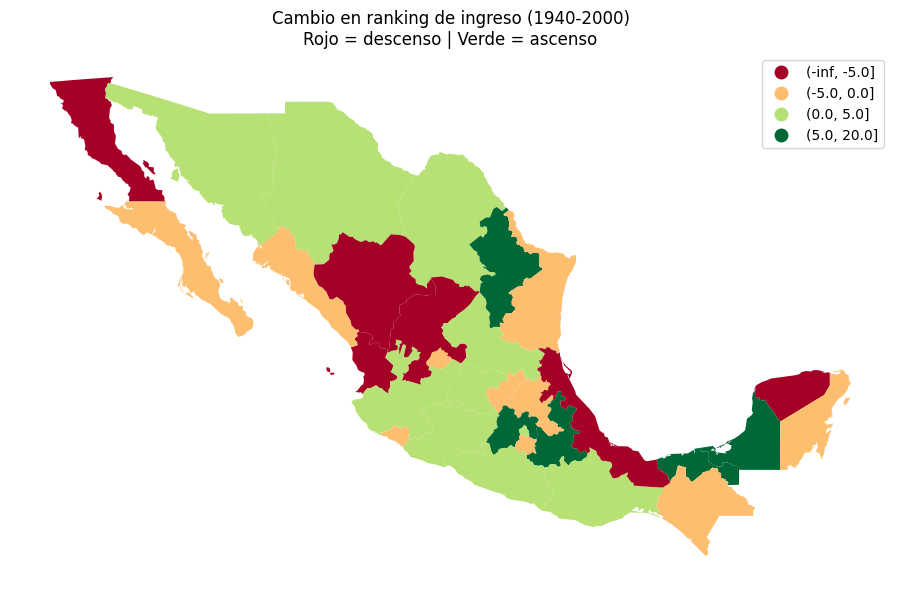

In [26]:
# Crear tabla de rankings por ingreso
rnk = mx[["NAME", "PCGDP1940", "PCGDP2000"]].rank(ascending=False)
rnk["cambio"] = rnk["PCGDP1940"] - rnk["PCGDP2000"]
rnk["clase"] = pandas.cut(
    rnk["cambio"], [-numpy.inf, -5, 0, 5, 20]
)

# Mapa divergente
fig, ax = plt.subplots(1, figsize=(10, 6))
(
    mx[["geometry"]]
    .join(rnk)
    .plot("clase", legend=True, cmap="RdYlGn", ax=ax)
)
ax.set_axis_off()
ax.set_title(
    "Cambio en ranking de ingreso (1940-2000)\n"
    "Rojo = descenso | Verde = ascenso",
    fontsize=12
)
plt.tight_layout()
plt.show()

### 6.3 Paletas cualitativas

Para **datos categóricos** donde los colores **no implican orden ni gradiente**, solo diferencia entre grupos.

**Importante:** No usar paletas secuenciales para variables nominales, porque sugieren erróneamente que una categoría es "mayor" que otra.

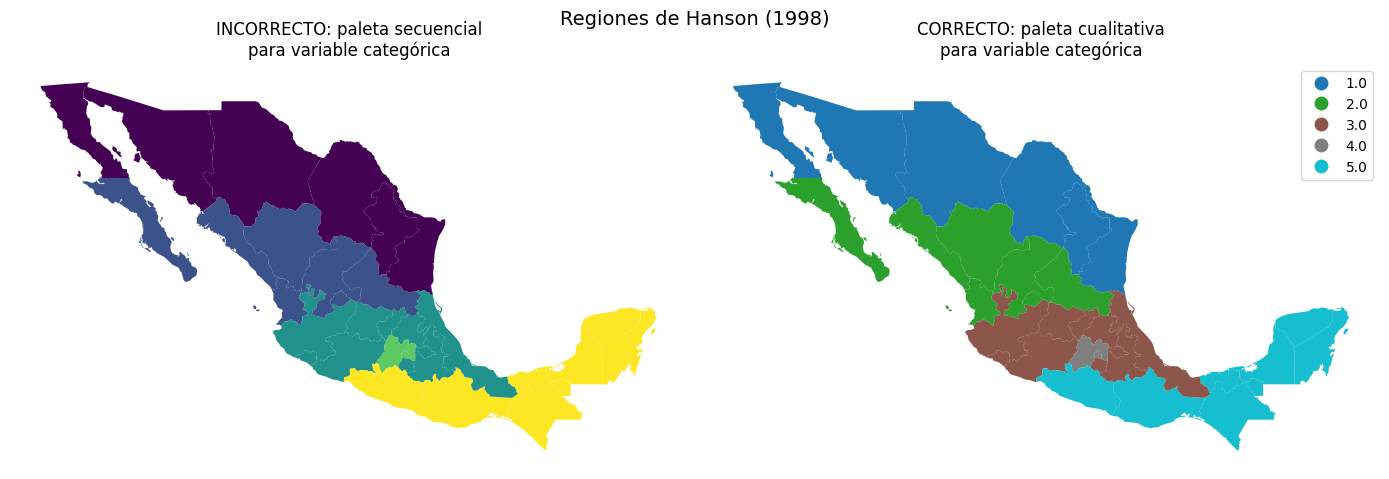

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# INCORRECTO: paleta secuencial para variable categórica
mx.plot("HANSON98", ax=axes[0])
axes[0].set_axis_off()
axes[0].set_title("INCORRECTO: paleta secuencial\npara variable categórica")

# CORRECTO: paleta cualitativa
mx.plot("HANSON98", categorical=True, legend=True, ax=axes[1])
axes[1].set_axis_off()
axes[1].set_title("CORRECTO: paleta cualitativa\npara variable categórica")

plt.suptitle("Regiones de Hanson (1998)", fontsize=14)
plt.tight_layout()
plt.show()

---

## 7. Temas avanzados

### 7.1 Clasificaciones definidas por el usuario

A veces necesitamos crear categorías basadas en **conocimiento del dominio** o **criterios de política pública**, no en un algoritmo estadístico.

**Ejemplo:** Supongamos que una política pública clasifica estados según su PIB per cápita en 2000:
- Menos de \$10,000
- Entre \$10,000 y \$12,500
- Entre \$12,500 y \$15,000
- Más de \$15,000

In [28]:
# Clasificación personalizada con mapclassify
classi = mapclassify.UserDefined(
    mx["PCGDP2000"], [10000, 12500, 15000]
)
classi

UserDefined

      Interval         Count
----------------------------
[ 8684.00, 10000.00] |     2
(10000.00, 12500.00] |     7
(12500.00, 15000.00] |     1
(15000.00, 54349.00] |    22

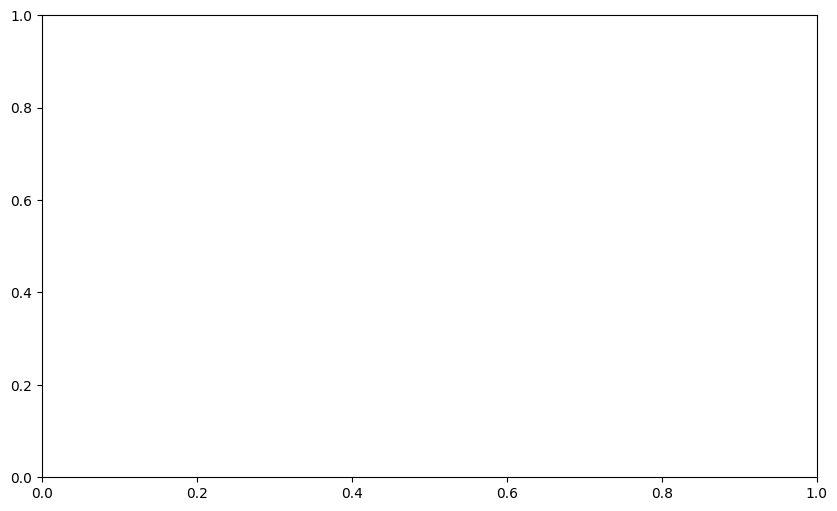

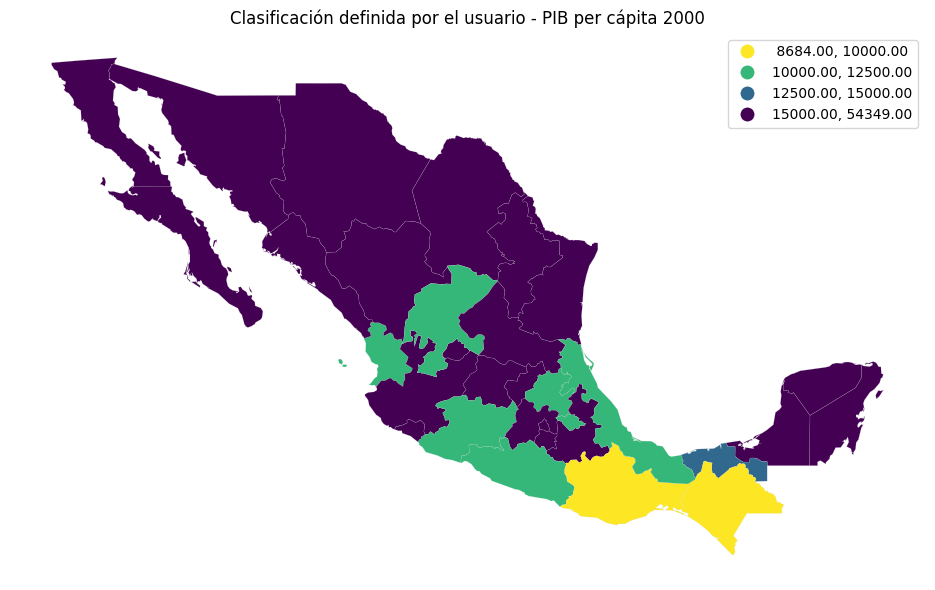

In [29]:
# Mapa con clasificación personalizada
fig, ax = plt.subplots(1, figsize=(10, 6))
classi.plot(
    mx, legend=True,
    legend_kwds={"loc": "upper right"},
    axis_on=False, cmap="viridis_r",
)
plt.title("Clasificación definida por el usuario - PIB per cápita 2000")
plt.tight_layout()
plt.show()

#### Alternativa con `pandas.cut`

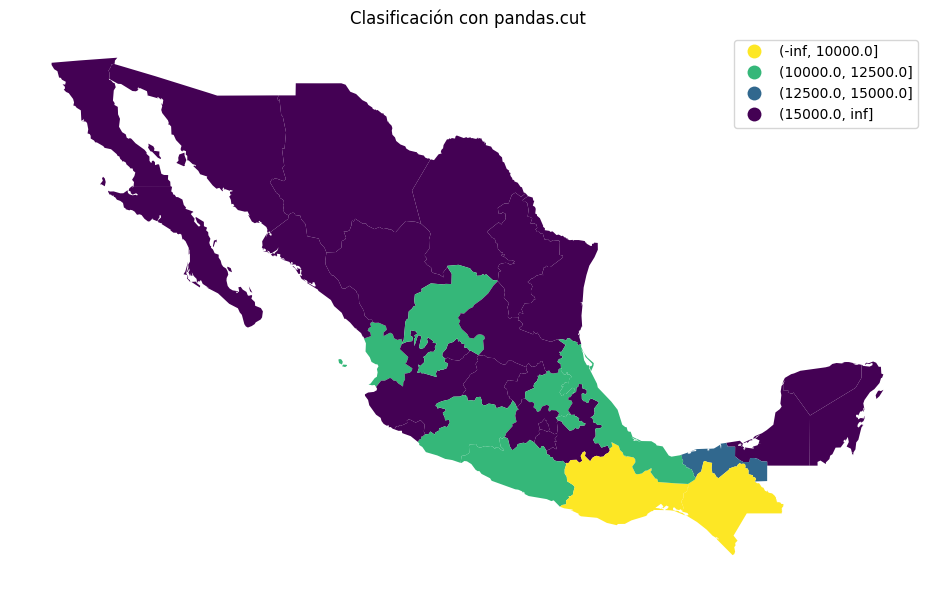

In [30]:
# Clasificar con pandas.cut
lbls = pandas.cut(
    mx["PCGDP2000"],
    [-numpy.inf, 10000, 12500, 15000, numpy.inf]
)

fig, ax = plt.subplots(1, figsize=(10, 6))
mx.plot(lbls, cmap="viridis_r", legend=True, ax=ax)
ax.set_axis_off()
ax.set_title("Clasificación con pandas.cut")
plt.tight_layout()
plt.show()

### 7.2 Clasificaciones agrupadas (*Pooled*)

Cuando creamos **múltiples mapas coropléticos** de la misma variable en distintos periodos, puede ser útil usar una **clasificación única** que sea coherente entre todos los mapas. Esto permite comparaciones visuales directas.

La clasificación *pooled* considera **todos los valores de todos los periodos** para definir los puntos de corte.

In [31]:
# Años a comparar
years = ["PCGDP1940", "PCGDP1960", "PCGDP1980", "PCGDP2000"]

# Clasificación pooled
pooled = mapclassify.Pooled(
    mx[years].values, classifier="Quantiles", k=5
)

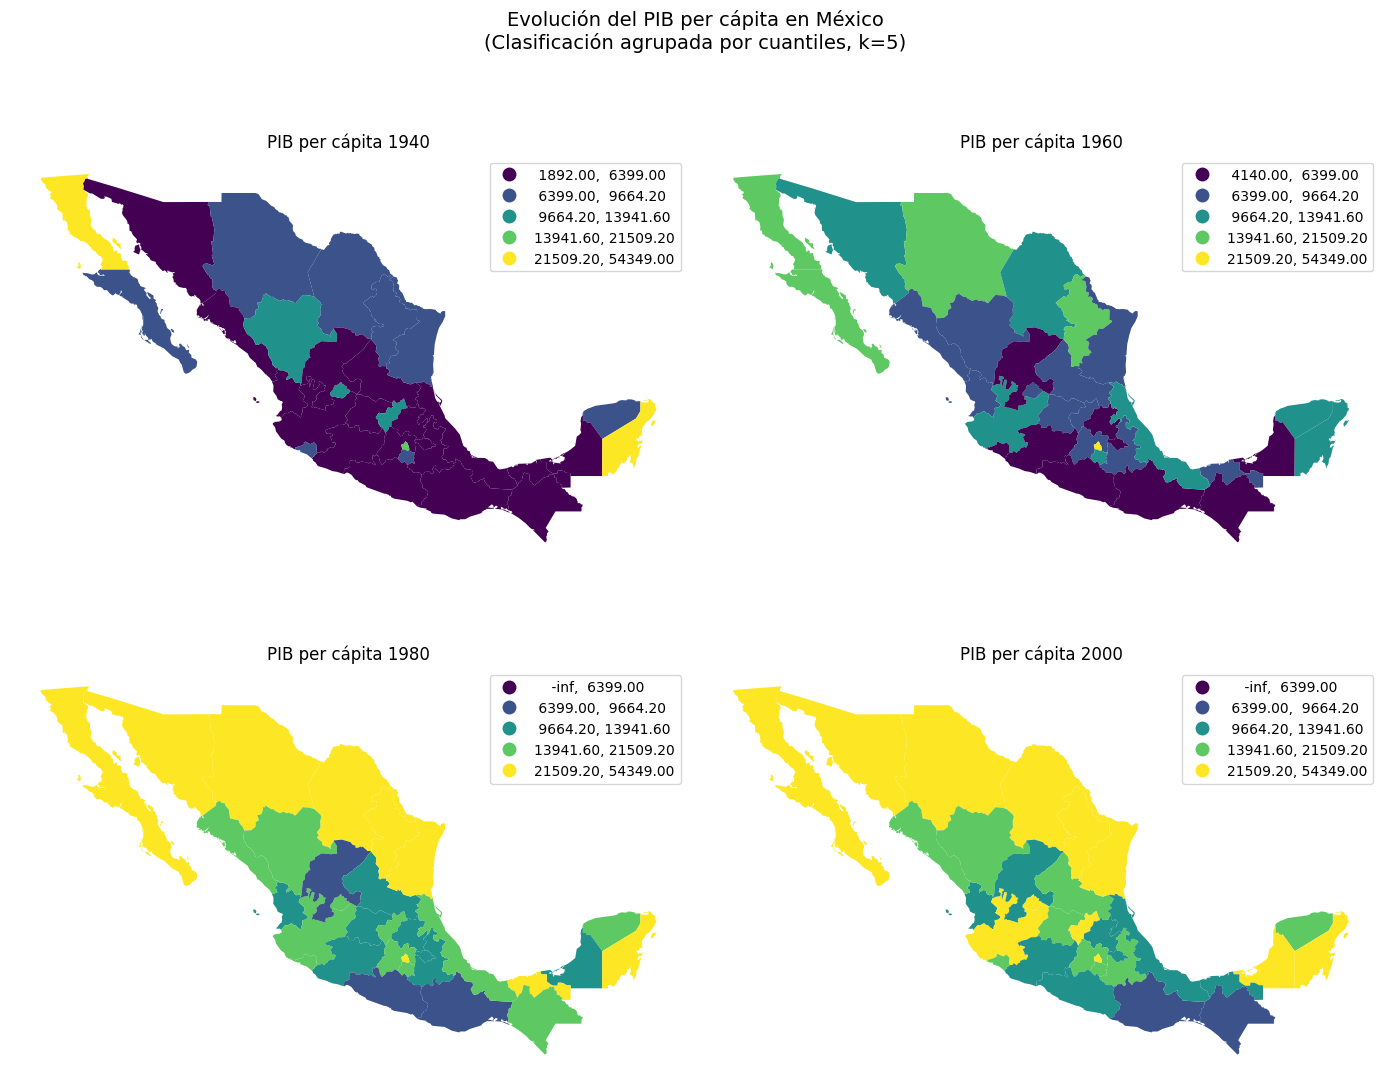

In [32]:
# Figura con 4 mapas usando la misma clasificación
f, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.flatten()

titulos = {
    "PCGDP1940": "PIB per cápita 1940",
    "PCGDP1960": "PIB per cápita 1960",
    "PCGDP1980": "PIB per cápita 1980",
    "PCGDP2000": "PIB per cápita 2000",
}

for i, y in enumerate(years):
    mx.plot(
        y,
        scheme="UserDefined",
        classification_kwds={
            "bins": pooled.global_classifier.bins
        },
        legend=True,
        ax=axs[i],
    )
    axs[i].set_axis_off()
    axs[i].set_title(titulos[y], fontsize=12)

plt.suptitle(
    "Evolución del PIB per cápita en México\n"
    "(Clasificación agrupada por cuantiles, k=5)",
    fontsize=14
)
plt.tight_layout()
plt.show()

---

## 8. Resumen de clasificadores

| Clasificador | Criterio | Ventaja principal | Limitación principal |
|:---|:---|:---|:---|
| Intervalos iguales | Ancho constante | Simple de interpretar | Sensible a valores extremos |
| Cuantiles | Misma cantidad por clase | Evita clases vacías | Anchos muy desiguales |
| Media-Desv. Est. | Distancia a la media | Bueno para datos normales | Malo para datos asimétricos |
| Cortes máximos | Brechas más grandes | Bueno para datos multimodales | Ignora matices dentro de clases |
| Box Plot | Percentiles + IQR | Identifica outliers | Número fijo de clases (6) |
| Head-Tail Breaks | Media recursiva | Ideal para colas pesadas | No permite fijar $k$ |
| Jenks-Caspall | Heurístico (K-Means 1D) | Buen balance general | No garantiza óptimo |
| **Fisher-Jenks** | **Programación dinámica** | **Solución óptima** | Más costoso computacionalmente |
| Max-P | Heurístico | Flexible | No garantiza óptimo |

## 9. Resumen de paletas de color

| Tipo de variable | Paleta recomendada | Ejemplos |
|:---|:---|:---|
| Continua / secuencial | Secuencial | `Blues`, `YlGn`, `viridis`, `Reds` |
| Continua con centro significativo | Divergente | `RdYlGn`, `RdBu`, `coolwarm` |
| Categórica / nominal | Cualitativa | `Set1`, `Set2`, `tab10`, `Paired` |

---

## 10. Ejercicios propuestos

1. **Asimetría y clasificación:** Una variable como la densidad de población suele ser muy asimétrica. ¿Qué clasificador elegirías y por qué?

2. **Empates en cuantiles:** Dada la serie $y = [2,2,2,2,2,2,4,7,8,9,20,21]$ con $k=4$, propón dos soluciones al problema de empates y discute sus méritos.

3. **Multimodalidad:** ¿Qué clasificadores son más apropiados para datos con distribución multimodal?

4. **Práctica con tus datos:** Elige un shapefile de tu país o región, selecciona una variable numérica, y crea mapas coropléticos con al menos 3 clasificadores diferentes. Compáralos usando ADCM.

5. **Paletas divergentes:** Crea una variable que represente el cambio porcentual en algún indicador y mapéala con una paleta divergente.

6. **Clasificación pooled:** Selecciona 3 o más variables temporales y crea un panel de mapas con clasificación agrupada. ¿Qué patrones de cambio observas?

7. **Reflexión:** ¿En qué medida los clasificadores más usados toman en cuenta la distribución *espacial* de la variable (además de la estadística)? ¿Se te ocurre alguna forma de incorporar la dimensión espacial en la clasificación?

---

## Referencias

- Rey, S. J., Arribas-Bel, D. y Wolf, L. J. (2020). *Geographic Data Science with Python*. Cap. 5: Choropleth Mapping.
- Jenks, G. F. y Caspall, F. C. (1971). Error on choroplethic maps. *Annals of the AAG*, 61(2), 217–244.
- Jiang, B. (2013). Head/tail breaks: A new classification scheme. *The Professional Geographer*, 65(3), 482–494.
- Slocum, T. A. et al. (2014). *Thematic Cartography and Geovisualization*. Pearson.
- Brewer, C. A. et al. (1997). Mapping mortality: evaluating color schemes for choropleth maps. *Annals of the AAG*, 87(3), 411–438.